In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy.io
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import statistics as stat

%matplotlib notebook

## Read dfbf

In [2]:
dfbf_file = "../../../soumyab/CalciumDataAnalysisResults/Preprocessed_files/G313/20200801/1/G313_20200801_wholeTrial_golshani_framebin3_gaussianKernel1.mat"

In [3]:
data_mat = scipy.io.loadmat(dfbf_file)
dfbf = data_mat["dfbf"]
print(f"This dataset has {dfbf.shape[0]} cells recorded over {dfbf.shape[1]} trials with {dfbf.shape[2]} frames")

FileNotFoundError: [Errno 2] No such file or directory: '../../../soumyab/CalciumDataAnalysisResults/Preprocessed_files/G313/20200801/1/G313_20200801_wholeTrial_golshani_framebin3_gaussianKernel1.mat'

## Session parameters

In [9]:
NUM_CELLS = dfbf.shape[0]
NUM_TRIALS = dfbf.shape[1]
NUM_FRAMES = dfbf.shape[2]
GROUP_SIZE = 5 #Number of trials per stim-type in multi-CS

CS_START_FRAME = int(8*NUM_FRAMES / 18)
TRACE_START_FRAME = int(8.05*NUM_FRAMES / 18)
US_START_FRAME = int(8.3*NUM_FRAMES / 18)
POST_START_FRAME = int(8.35*NUM_FRAMES / 18)
CS_START_FRAME

96

In [10]:
def plot_trial_average(data):
    plt.figure()
    for i in range(data.shape[0]):
        plt.plot(np.arange(data.shape[2]), np.mean(data, axis=1)[i])
    plt.xlabel("Frame #")
    plt.ylabel("dfbf")
    plt.title(f"Trial averaged dfbf")
    plt.figure()
    plt.imshow(np.mean(data, axis=1))

In [11]:
def plot_cell_traces(data, cell_num):
    plt.figure()
    for i in range(data.shape[1]):
        plt.plot(np.arange(data.shape[2]), 2*i + data[cell_num,i,:])
    plt.xlabel("Frame #")
    plt.ylabel("2 * Trial #")
    plt.title(f"Cell #{cell_num}")

<IPython.core.display.Javascript object>


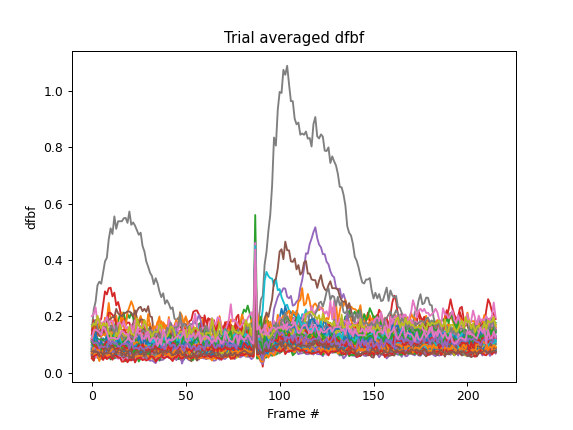

<IPython.core.display.Javascript object>


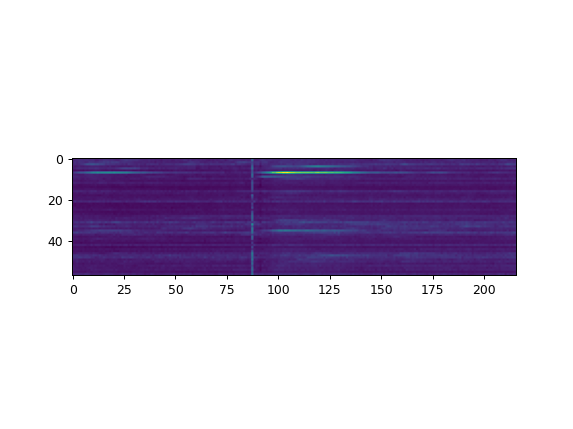

In [12]:
plot_trial_average(dfbf)

<IPython.core.display.Javascript object>


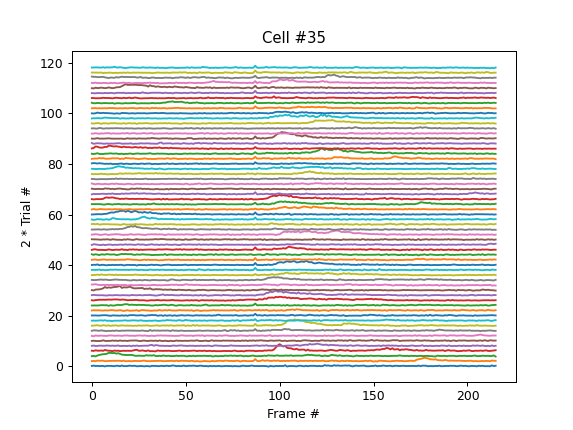

In [13]:
plot_cell_traces(dfbf, 35)

<span style='color:red'> **This is a mixed session. So light artifact(the spike at around frame #87) is supposed to come in alternating sets of 5 trials. But that's not what we see here. So most likely the trials are mixed up. Also, CS frame by calculation is supposed to be 96, but here we see the artifact at 87.** </span>

## Reshaping the data to 2D

In [56]:
def reshape_data_3D_to_2D(data_3D):
    data_2D = np.reshape(data_3D, (data_3D.shape[0], data_3D.shape[1]*data_3D.shape[2])).T
    return data_2D

In [61]:
def perform_PCA(x, y, num_trials=None):
    x = StandardScaler().fit_transform(x)
    pca = PCA(n_components=3)
    principalComponents = pca.fit_transform(x)

    principalDf = pd.DataFrame(data = principalComponents
             , columns = ['PC1', 'PC2', 'PC3'])
    finalDf = pd.concat([principalDf, pd.Series(y, name="US_type")], axis = 1)
    print(pca.explained_variance_ratio_)
    
    
    #Plot datapoints as scatter
    fig = plt.figure(figsize = (8,8))
    ax = fig.add_subplot(projection='3d')
    
    ax.set_xlabel('PC1', fontsize = 15)
    ax.set_ylabel('PC2', fontsize = 15)
    ax.set_zlabel('PC3', fontsize = 15)
    ax.set_title('Scatter plot traces', fontsize = 20)
    targets = [0, 1]
    colors = ['r', 'b']
    stim = ["sound", "light"]
    for target, color in zip(targets,colors):
        indicesToKeep = finalDf['US_type'] == target
        ax.scatter(finalDf.loc[indicesToKeep, 'PC1']
                   , finalDf.loc[indicesToKeep, 'PC2']
                   , finalDf.loc[indicesToKeep, 'PC3']
                   , c = color
                   , s = 50
                   , alpha = 0.5
                   , label=stim[target])
    ax.legend()
    ax.grid()
    
    #Plot datapoints as traces
    num_frames = np.int(x.shape[0] / num_trials)
    fig2 = plt.figure(figsize = (8,8))
    ax2 = fig2.add_subplot(projection='3d')
    
    ax2.set_xlabel('PC1', fontsize = 15)
    ax2.set_ylabel('PC2', fontsize = 15)
    ax2.set_zlabel('PC3', fontsize = 15)
    ax2.set_title('Line plot of traces', fontsize = 20)
    targets = [0, 1]
        
  
    for t_num in range(num_trials):
        color = colors[stat.mode(y[t_num*num_frames:(t_num+1)*num_frames])]
        ax2.plot(finalDf.loc[t_num*num_frames:(t_num+1)*num_frames, 'PC1']
                   , finalDf.loc[t_num*num_frames:(t_num+1)*num_frames, 'PC2']
                   , finalDf.loc[t_num*num_frames:(t_num+1)*num_frames, 'PC3']
                   , c = color
                   , alpha = 0.5)
    ax2.grid()

# PCA on whole dataset

[0.13525475 0.04437198 0.03080391]


<IPython.core.display.Javascript object>


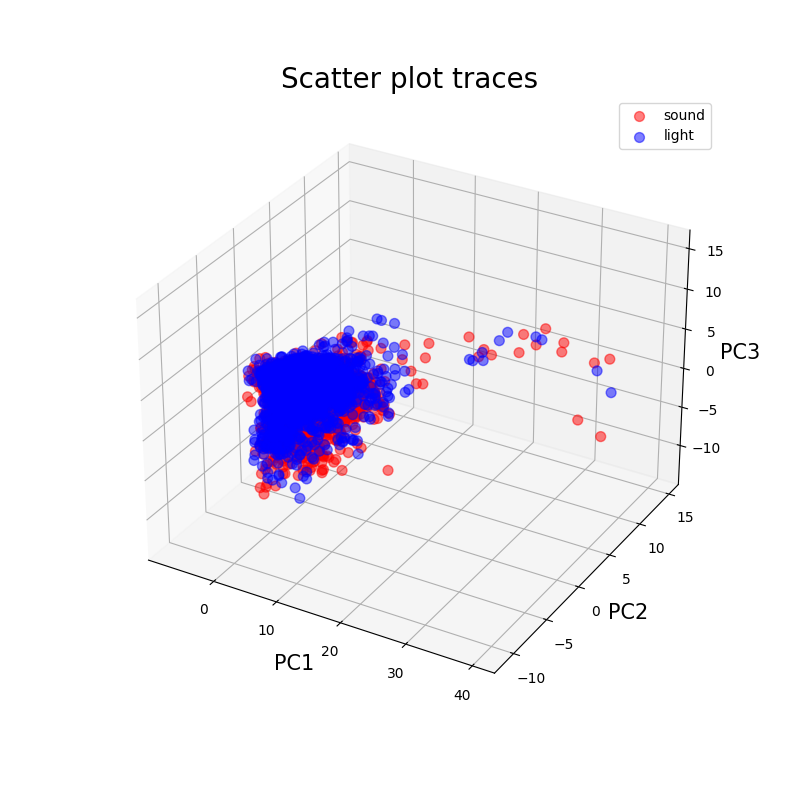

<IPython.core.display.Javascript object>


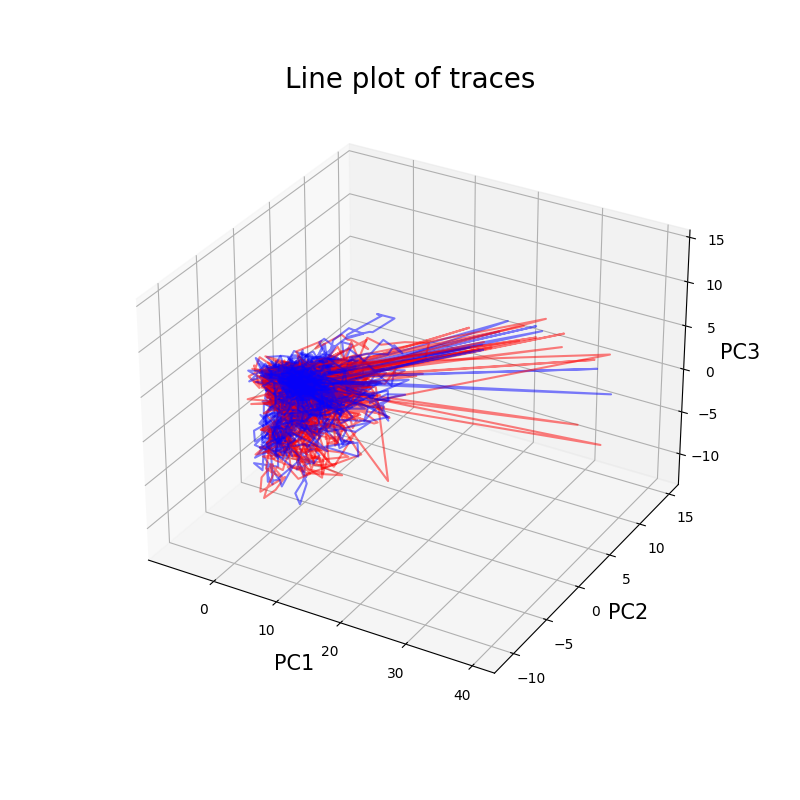

In [62]:
dataset = dfbf
X = reshape_data_3D_to_2D(dataset)
Y = np.array([(i//(GROUP_SIZE*dataset.shape[2]))%2 for i in range(X.shape[0])])
perform_PCA(X, Y, num_trials=dfbf.shape[1])

# Pre-stim data

(57, 60, 96)
[0.17254289 0.0437961  0.03128252]


<IPython.core.display.Javascript object>


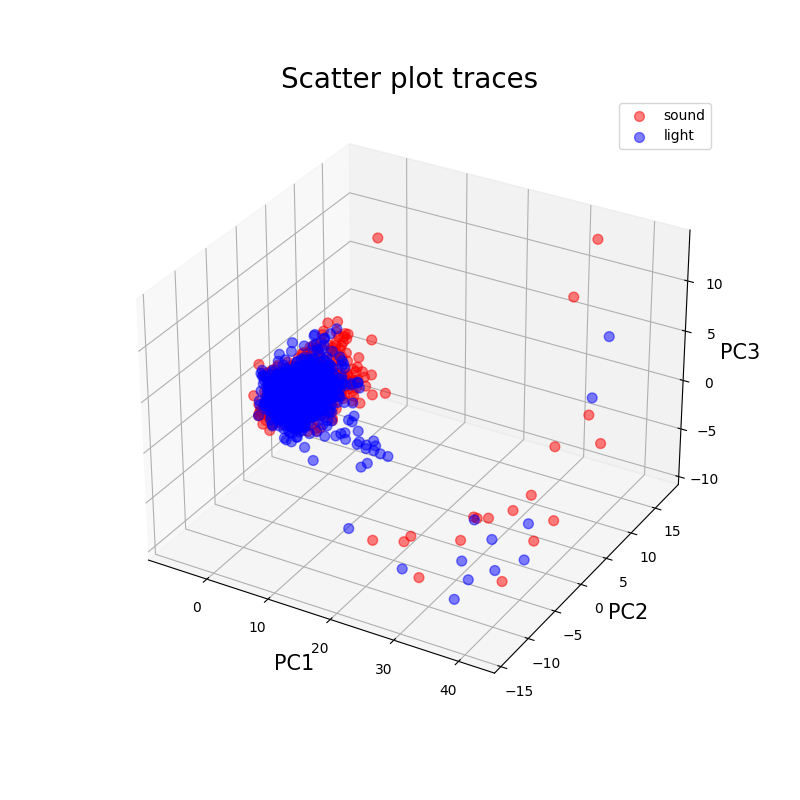

<IPython.core.display.Javascript object>


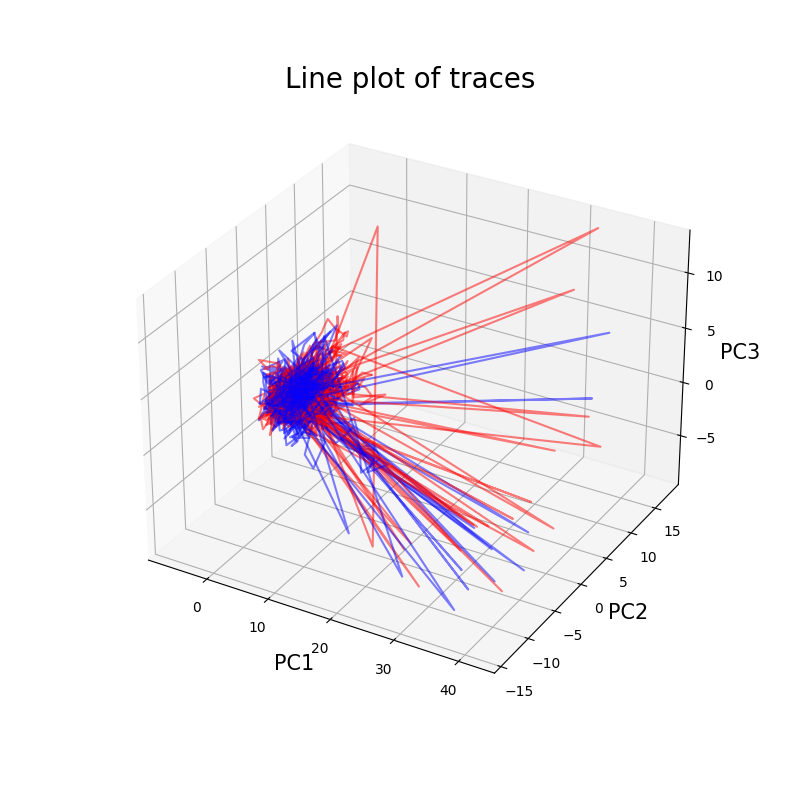

In [63]:
dataset = dfbf[:,:,:CS_START_FRAME]
print(dataset.shape)
X = reshape_data_3D_to_2D(dataset)
Y = np.array([(i//(GROUP_SIZE*dataset.shape[2]))%2 for i in range(X.shape[0])])
perform_PCA(X, Y, num_trials=dfbf.shape[1])

# CS to US data

[0.14741715 0.06486638 0.04819631]


<IPython.core.display.Javascript object>


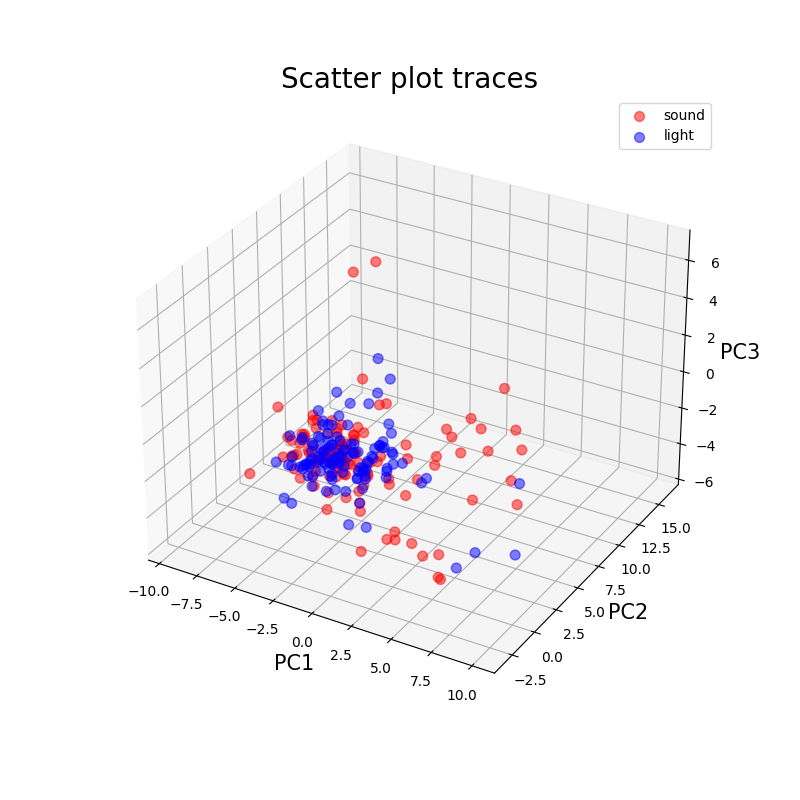

<IPython.core.display.Javascript object>


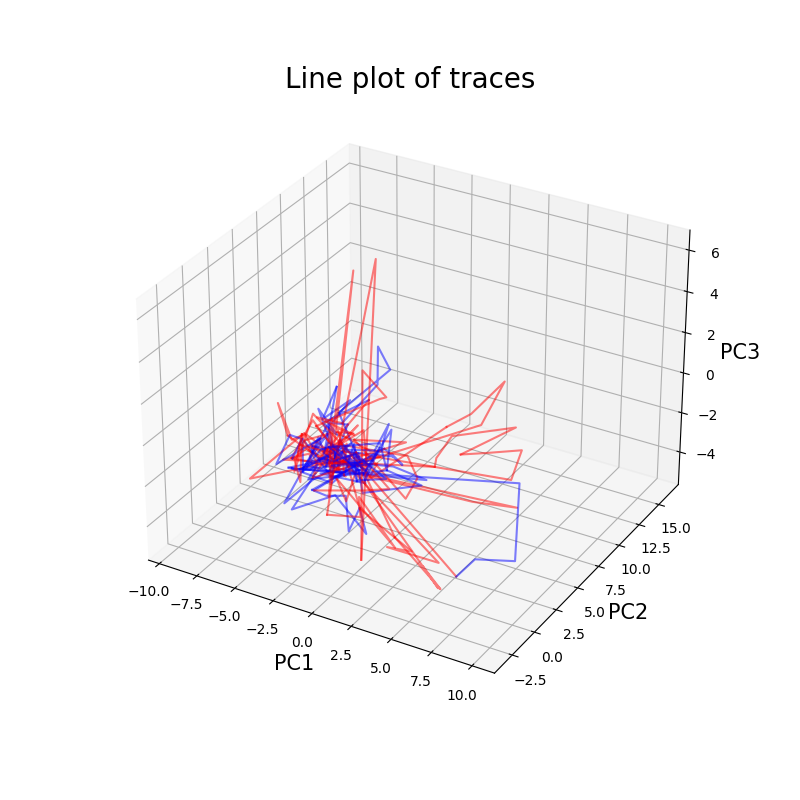

In [64]:
dataset = dfbf[:,:,CS_START_FRAME:POST_START_FRAME]
X = reshape_data_3D_to_2D(dataset)
Y = np.array([(i//(GROUP_SIZE*dataset.shape[2]))%2 for i in range(X.shape[0])])
perform_PCA(X, Y, num_trials=dfbf.shape[1])

# Post data

[0.10416231 0.04757463 0.03196404]


<IPython.core.display.Javascript object>


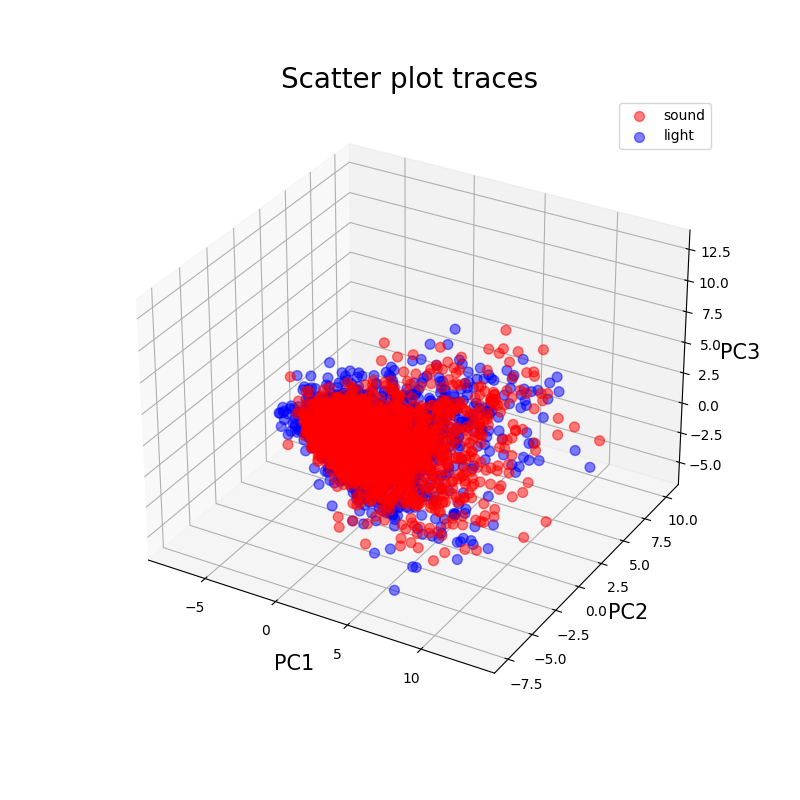

<IPython.core.display.Javascript object>


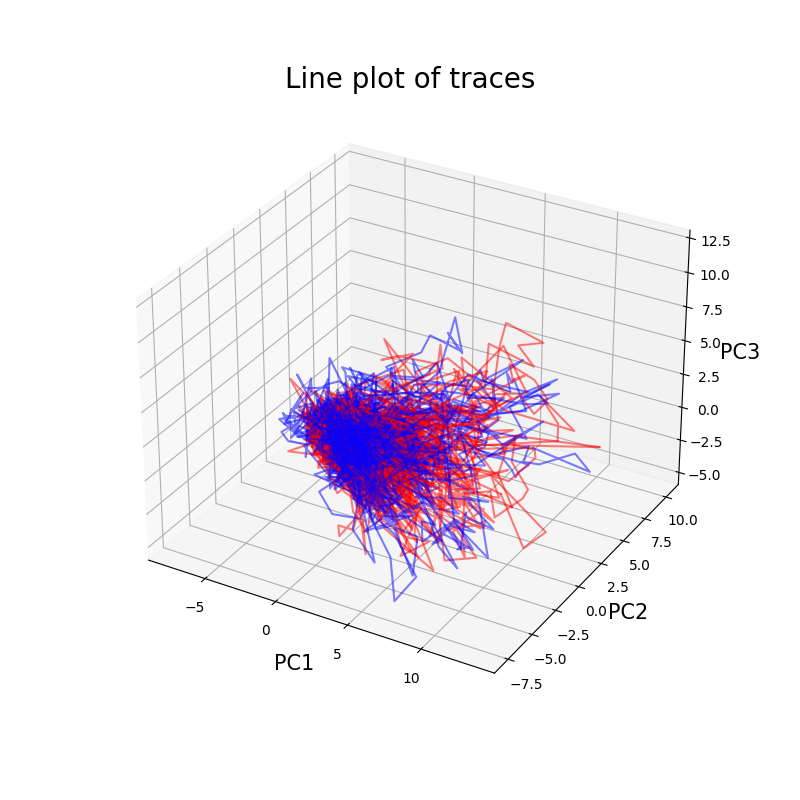

In [65]:
dataset = dfbf[:,:,POST_START_FRAME:]
X = reshape_data_3D_to_2D(dataset)
Y = np.array([(i//(GROUP_SIZE*dataset.shape[2]))%2 for i in range(X.shape[0])])
perform_PCA(X, Y, num_trials=dfbf.shape[1])

<span style='color:red'> **Hard to interpret anything as I think the trials need to be properly sorted** </span>